**Set-up ambiente**

In [1]:
import subprocess
subprocess.run(["pip", "install", "-q", "--force-reinstall", "opencv-python-headless==4.9.0.80"])

CompletedProcess(args=['pip', 'install', '-q', '--force-reinstall', 'opencv-python-headless==4.9.0.80'], returncode=0)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -r /content/drive/MyDrive/FAIML-RL-26/requirements.txt -q

%cd /content/drive/MyDrive/FAIML-RL-26/part2/panda-gym
!pip install -e .

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/FAIML-RL-26/part2/panda-gym
Obtaining file:///content/drive/MyDrive/FAIML-RL-26/part2/panda-gym
  Preparing metadata (setup.py) ... done
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
  Attempting uninstall: panda_gym
    Found existing installation: panda_gym 3.0.8
    Uninstalling panda_gym-3.0.8:
      Successfully uninstalled panda_gym-3.0.8
  Running setup.py develop for panda_gym
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following depend

**Import necessari**

In [3]:
from collections import deque

import gymnasium as gym
import numpy as np
import panda_gym  # type: ignore[import-not-found]
#from stable_baselines3 import DDPG
#from rand_wrapper import RandomizationWrapper
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback, CallbackList
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Main batch_size più grande**

In [ ]:
def main() -> None:
    #args = parse_args()

    env = gym.make(
        "PandaPush-v3",
        render_mode="rgb_array",
        type="source",
        reward_type="dense",
    )

    # Ambiente di valutazione SEPARATO (obbligatorio per EvalCallback)
    eval_env = gym.make(
        "PandaPush-v3",
        render_mode="rgb_array",
        type="source",
        reward_type="dense",
    )

    checkpoint_callback = CheckpointCallback(
      save_freq=50000,
      save_path="/content/drive/MyDrive/FAIML-RL-26/checkpoints/",
      name_prefix="sac_source",
      save_replay_buffer=True,
    )

    # Valuta ogni 50k timesteps e salva il modello migliore
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"/content/drive/MyDrive/FAIML-RL-26/evalcallback/sac_source/batch_size/",
        log_path=f"/content/drive/MyDrive/FAIML-RL-26/evalcallback/sac_source/batch_size/",
        eval_freq=50000,
        n_eval_episodes=20,
        deterministic=True,
        verbose=1,
    )

    #TODO: add randomization wrapper here
    #TODO: create model and train it
    model = SAC("MultiInputPolicy", env, verbose=1, seed=42, batch_size=512, device="cuda")
    model.learn(total_timesteps=500000, callback=CallbackList([checkpoint_callback, eval_callback]))
    save_name = f"sac_push_none_source_500000_batchsize"
    # TODO: model.save(save_name)
    model.save(f"/content/drive/MyDrive/FAIML-RL-26/results/sac_source/{save_name}")

**Main learning_rate più piccolo**

In [ ]:
def main() -> None:
    #args = parse_args()

    env = gym.make(
        "PandaPush-v3",
        render_mode="rgb_array",
        type="source",
        reward_type="dense",
    )

    # Ambiente di valutazione SEPARATO (obbligatorio per EvalCallback)
    eval_env = gym.make(
        "PandaPush-v3",
        render_mode="rgb_array",
        type="source",
        reward_type="dense",
    )

    checkpoint_callback = CheckpointCallback(
      save_freq=50000,
      save_path="/content/drive/MyDrive/FAIML-RL-26/checkpoints/",
      name_prefix="sac_source",
      save_replay_buffer=True,
    )

    # Valuta ogni 50k timesteps e salva il modello migliore
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"/content/drive/MyDrive/FAIML-RL-26/evalcallback/sac_source/learning_rate/",
        log_path=f"/content/drive/MyDrive/FAIML-RL-26/evalcallback/sac_source/learning_rate/",
        eval_freq=50000,
        n_eval_episodes=20,
        deterministic=True,
        verbose=1,
    )

    #TODO: add randomization wrapper here
    #TODO: create model and train it
    model = SAC("MultiInputPolicy", env, verbose=1, seed=42, batch_size=512, learning_rate=1e-4, device="cuda")
    model.learn(total_timesteps=500000, callback=CallbackList([checkpoint_callback, eval_callback]))
    save_name = f"sac_push_none_source_500000_learningrate"
    # TODO: model.save(save_name)
    model.save(f"/content/drive/MyDrive/FAIML-RL-26/results/sac_source/{save_name}")

**Main su targer con batch size aumentato**

In [4]:
def main() -> None:
    #args = parse_args()

    env = gym.make(
        "PandaPush-v3",
        render_mode="rgb_array",
        type="target",
        reward_type="dense",
    )

    # Ambiente di valutazione SEPARATO (obbligatorio per EvalCallback)
    eval_env = gym.make(
        "PandaPush-v3",
        render_mode="rgb_array",
        type="target",
        reward_type="dense",
    )

    checkpoint_callback = CheckpointCallback(
      save_freq=50000,
      save_path="/content/drive/MyDrive/FAIML-RL-26/checkpoints/",
      name_prefix="sac_target",
      save_replay_buffer=True,
    )

    # Valuta ogni 50k timesteps e salva il modello migliore
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"/content/drive/MyDrive/FAIML-RL-26/evalcallback/sac_target/",
        log_path=f"/content/drive/MyDrive/FAIML-RL-26/evalcallback/sac_target/",
        eval_freq=50000,
        n_eval_episodes=20,
        deterministic=True,
        verbose=1,
    )

    #TODO: add randomization wrapper here
    #TODO: create model and train it
    model = SAC("MultiInputPolicy", env, verbose=1, seed=42, batch_size=512, device="cuda")
    model.learn(total_timesteps=500000, callback=CallbackList([checkpoint_callback, eval_callback]))
    save_name = f"sac_push_none_target_500000"
    # TODO: model.save(save_name)
    model.save(f"/content/drive/MyDrive/FAIML-RL-26/results/sac_target/{save_name}")

**Train**

In [5]:
if __name__ == "__main__":
    main()

Created object with mass: 5.0
Created object with mass: 5.0
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 37.8     |
|    ep_rew_mean     | -3.62    |
|    success_rate    | 0.25     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 54       |
|    time_elapsed    | 2        |
|    total_timesteps | 151      |
| train/             |          |
|    actor_loss      | -3.7     |
|    critic_loss     | 0.33     |
|    ent_coef        | 0.985    |
|    ent_coef_loss   | -0.0739  |
|    learning_rate   | 0.0003   |
|    n_updates       | 50       |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Output streaming troncato alle ultime 5000 righe.
|    success_rate    | 0.21     |
| time/              |          |
|    episodes        | 136      |
|    fps             | 19       |
|    time_elapsed    | 269      |
|    total_timesteps | 5393     |
| train/             |          |
|    actor_loss      | -17.8    |
|    critic_loss     | 0.991    |
|    ent_coef        | 0.207    |
|    ent_coef_loss   | -7.5     |
|    learning_rate   | 0.0003   |
|    n_updates       | 5292     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 40.5     |
|    ep_rew_mean     | -4.23    |
|    success_rate    | 0.2      |
| time/              |          |
|    episodes        | 140      |
|    fps             | 20       |
|    time_elapsed    | 279      |
|    total_timesteps | 5593     |
| train/             |          |
|    actor_loss      | -17.7    |
|    critic_loss     | 0.946    |
|    ent_coef        | 0.195    

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Output streaming troncato alle ultime 5000 righe.
| time/              |          |
|    episodes        | 24084    |
|    fps             | 18       |
|    time_elapsed    | 25990    |
|    total_timesteps | 490513   |
| train/             |          |
|    actor_loss      | 3.2      |
|    critic_loss     | 0.119    |
|    ent_coef        | 0.00722  |
|    ent_coef_loss   | -0.975   |
|    learning_rate   | 0.0003   |
|    n_updates       | 490412   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 8.73     |
|    ep_rew_mean     | -0.647   |
|    success_rate    | 0.97     |
| time/              |          |
|    episodes        | 24088    |
|    fps             | 18       |
|    time_elapsed    | 25991    |
|    total_timesteps | 490540   |
| train/             |          |
|    actor_loss      | 3.04     |
|    critic_loss     | 0.103    |
|    ent_coef        | 0.00717  |
|    ent_coef_loss   | 0.344    

**Curva di apprendimento**

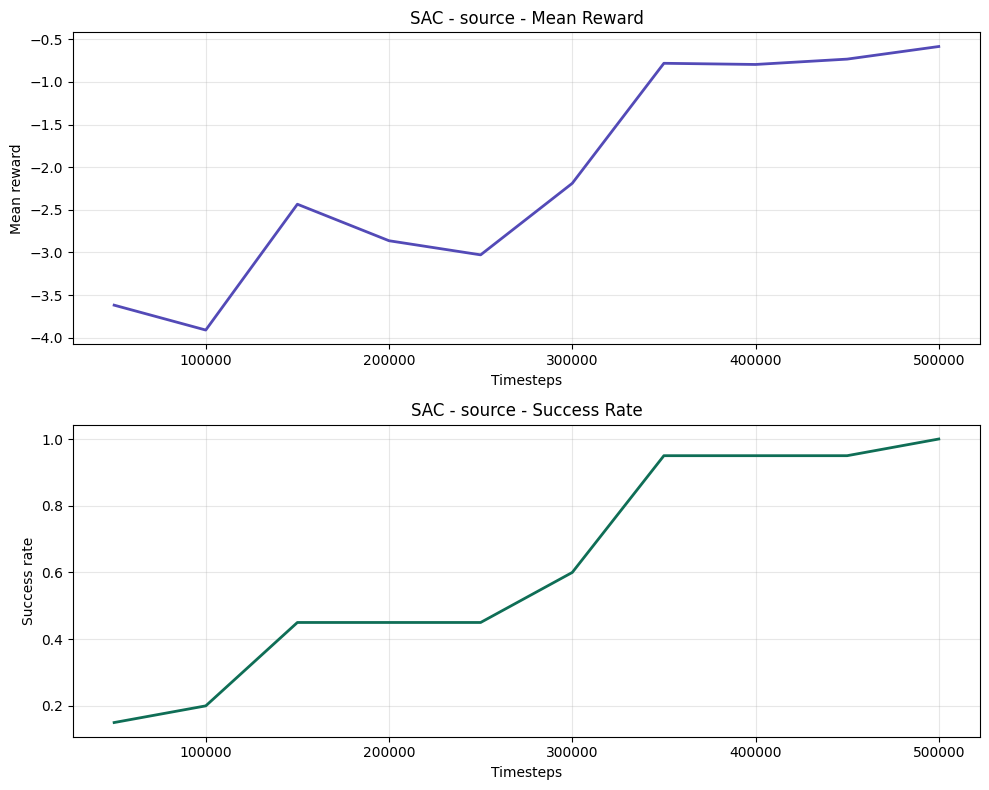

In [6]:
# Carica i dati dell'EvalCallback
data = np.load("/content/drive/MyDrive/FAIML-RL-26/evalcallback/sac_target/evaluations.npz")

timesteps = data['timesteps']
mean_rewards = data['results'].mean(axis=1)
success_rates = data['successes'].mean(axis=1)

# Grafico
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(timesteps, mean_rewards, color='#534AB7', linewidth=2)
ax1.set_xlabel('Timesteps')
ax1.set_ylabel('Mean reward')
ax1.set_title('SAC - source - Mean Reward')
ax1.grid(True, alpha=0.3)

ax2.plot(timesteps, success_rates, color='#0F6E56', linewidth=2)
ax2.set_xlabel('Timesteps')
ax2.set_ylabel('Success rate')
ax2.set_title('SAC - source - Success Rate')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FAIML-RL-26/results/sac_target/learning_curve_target.png", dpi=150)
plt.show()